# EDA — TweetEval: Sentiment & Stance

Análisis exploratorio de los datasets del benchmark TweetEval utilizados en este TFM.
Los resultados de este notebook alimentan la sección **2.4.2 Análisis exploratorio de los datos** de la memoria.

**Datos:** `tweeteval/datasets/sentiment/` y `tweeteval/datasets/stance/`

In [16]:
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)
plt.rcParams["figure.dpi"] = 120

DATA_ROOT = Path("/Users/jimenamillamoreno/Desktop/TFM/tweeteval/datasets")
FIGURES   = Path("figures")
FIGURES.mkdir(exist_ok=True)

In [17]:
# ── helpers ──────────────────────────────────────────────────────────────────

def load_split(task_dir: Path, split: str) -> pd.DataFrame:
    texts  = (task_dir / f"{split}_text.txt").read_text(encoding="utf-8").splitlines()
    labels = (task_dir / f"{split}_labels.txt").read_text(encoding="utf-8").splitlines()
    return pd.DataFrame({"text": texts, "label": list(map(int, labels)), "split": split})

def load_mapping(task_dir: Path) -> dict:
    # stance targets no tienen mapping.txt propio — está en el directorio padre
    for candidate in [task_dir / "mapping.txt", task_dir.parent / "mapping.txt"]:
        if candidate.exists():
            lines = candidate.read_text(encoding="utf-8").splitlines()
            return {int(l.split()[0]): l.split()[1] for l in lines if l.strip()}
    raise FileNotFoundError(f"mapping.txt not found in {task_dir} or {task_dir.parent}")

def load_task(task_dir: Path):
    mapping = load_mapping(task_dir)
    df = pd.concat([load_split(task_dir, s) for s in ("train", "val", "test")], ignore_index=True)
    df["label_name"] = df["label"].map(mapping)
    df["n_chars"]    = df["text"].str.len()
    df["n_tokens"]   = df["text"].str.split().str.len()
    return df, mapping

STOPWORDS = {
    "the","a","an","is","it","in","of","to","and","for","on","at","this",
    "that","with","be","are","was","i","you","he","she","we","they","my",
    "me","your","its","as","not","so","or","but","if","do","have","has",
    "had","will","would","can","could","his","her","our","their",
    "all","just","about","more","no","up","by","from","than","what",
    "httpurl","@user","rt","&amp;","...","", "–","-","|","'s","'t","don",
    "semst","sem","st"
}

def top_tokens(texts, n=20, hashtags_only=False):
    tokens = []
    for t in texts:
        words = re.findall(r'#?\w+', t.lower())
        if hashtags_only:
            words = [w for w in words if w.startswith("#")]
        else:
            words = [w for w in words if w not in STOPWORDS and len(w) > 2]
        tokens.extend(words)
    return Counter(tokens).most_common(n)

---
## 1. Sentiment Analysis

In [18]:
sent_df, sent_map = load_task(DATA_ROOT / "sentiment")
print("Mapping:", sent_map)
print(f"Total tweets: {len(sent_df):,}")
sent_df.head(3)

Mapping: {0: 'negative', 1: 'neutral', 2: 'positive'}
Total tweets: 59,899


,text,label,split,label_name,n_chars,n_tokens
0,"""QT @user In the original draft of the 7th boo...",2,train,positive,120,18
1,"""Ben Smith / Smith (concussion) remains out of...",1,train,neutral,85,14
2,Sorry bout the stream last night I crashed out...,1,train,neutral,125,24


### 1.1 Distribución de muestras por split

In [19]:
split_counts = sent_df.groupby("split").size().reindex(["train","val","test"])
print(split_counts.to_string())
print(f"\nTotal: {split_counts.sum():,}")

split
train    45615
val       2000
test     12284

Total: 59,899


### 1.2 Distribución de clases por split

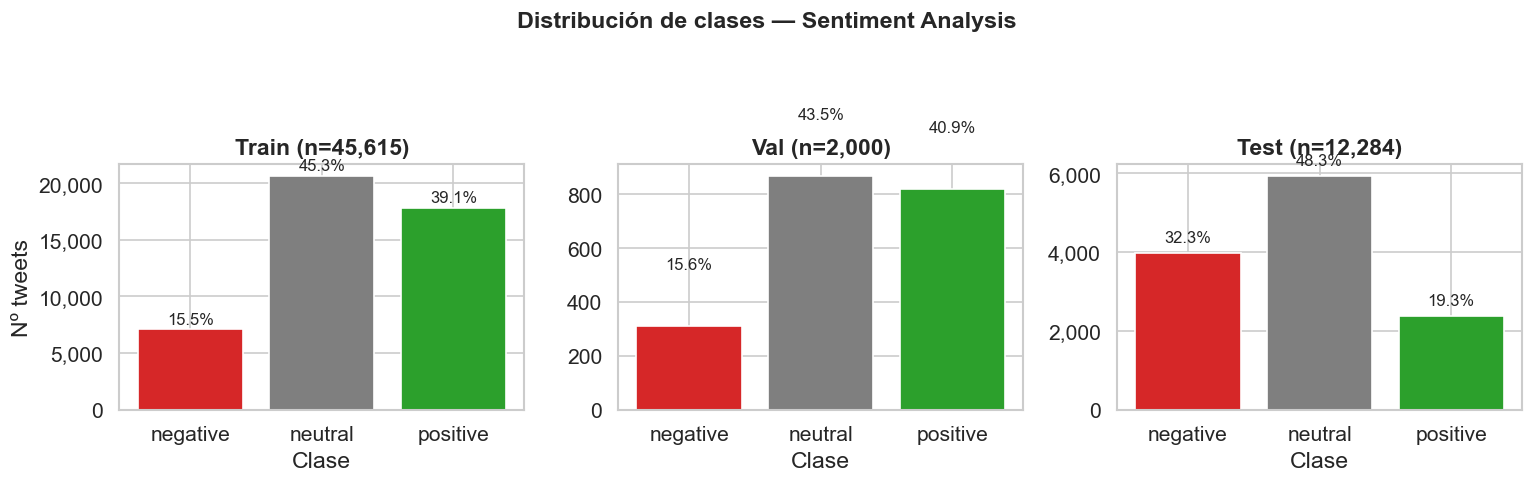

In [20]:
label_order = [sent_map[k] for k in sorted(sent_map)]
SENT_COLORS = {"negative": "#d62728", "neutral": "#7f7f7f", "positive": "#2ca02c"}

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)

for ax, split in zip(axes, ["train", "val", "test"]):
    sub = sent_df[sent_df["split"] == split]
    counts = sub["label_name"].value_counts().reindex(label_order)
    pcts   = counts / counts.sum() * 100
    bars = ax.bar(label_order, counts, color=[SENT_COLORS[l] for l in label_order])
    for bar, pct in zip(bars, pcts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f"{pct:.1f}%", ha="center", va="bottom", fontsize=10)
    ax.set_title(f"{split.capitalize()} (n={len(sub):,})", fontweight="bold")
    ax.set_xlabel("Clase")
    ax.set_ylabel("Nº tweets" if split == "train" else "")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

fig.suptitle("Distribución de clases — Sentiment Analysis", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / "sent_label_distribution.png", bbox_inches="tight")
plt.show()

### 1.3 Longitud de tweets

In [21]:
print("Estadísticas de longitud (tokens) — train:")
print(sent_df[sent_df["split"]=="train"]["n_tokens"].describe().round(1).to_string())

Estadísticas de longitud (tokens) — train:
count    45615.0
mean        19.2
std          4.9
min          1.0
25%         16.0
50%         20.0
75%         23.0
max         35.0


/var/folders/bq/6pxdsh8107s4_tvgz_5dhtj40000gn/T/ipykernel_27217/459583921.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x="label_name", y="n_tokens",


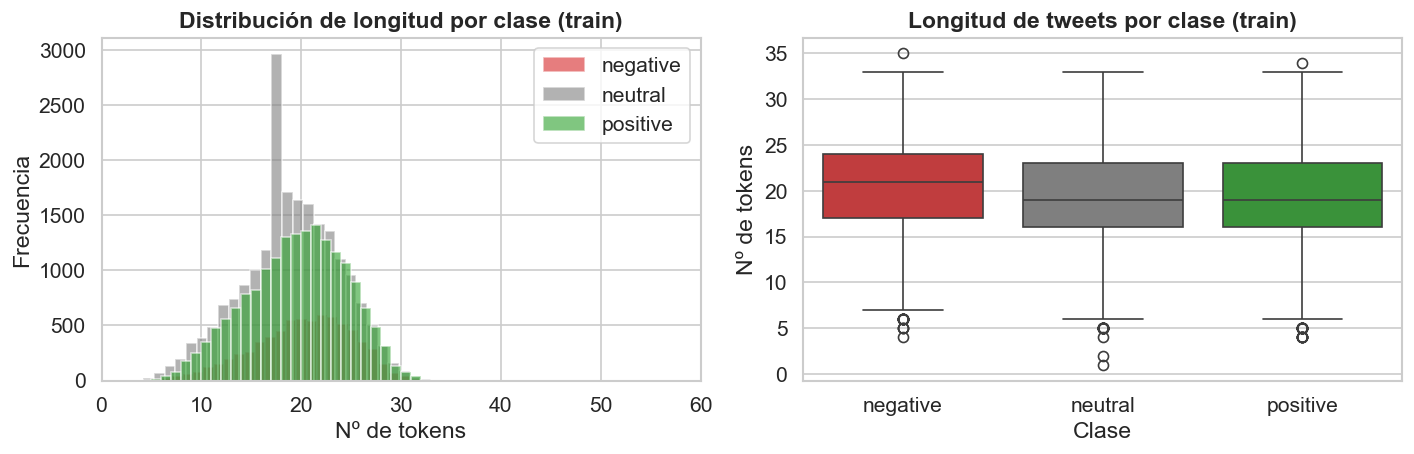

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribución por clase (train)
train_df = sent_df[sent_df["split"] == "train"]
for label in label_order:
    subset = train_df[train_df["label_name"] == label]["n_tokens"]
    axes[0].hist(subset, bins=30, alpha=0.6, label=label, color=SENT_COLORS[label])
axes[0].set_xlabel("Nº de tokens")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribución de longitud por clase (train)", fontweight="bold")
axes[0].legend()
axes[0].set_xlim(0, 60)

# Boxplot por clase
sns.boxplot(data=train_df, x="label_name", y="n_tokens",
            order=label_order,
            palette=SENT_COLORS,
            ax=axes[1])
axes[1].set_xlabel("Clase")
axes[1].set_ylabel("Nº de tokens")
axes[1].set_title("Longitud de tweets por clase (train)", fontweight="bold")

plt.tight_layout()
plt.savefig(FIGURES / "sent_tweet_length.png", bbox_inches="tight")
plt.show()

### 1.4 Tokens más frecuentes por clase

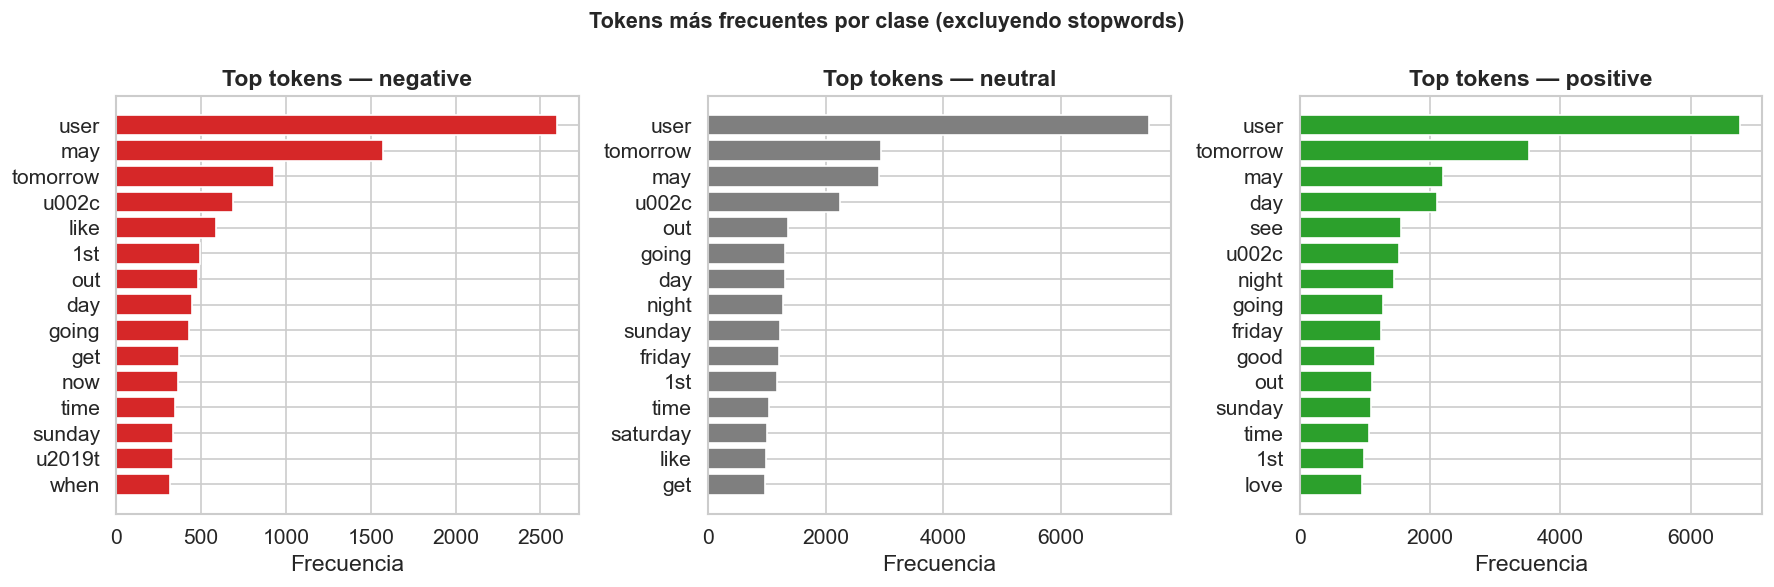

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, label in zip(axes, label_order):
    texts = train_df[train_df["label_name"] == label]["text"]
    top = top_tokens(texts, n=15)
    words, freqs = zip(*top)
    ax.barh(list(reversed(words)), list(reversed(freqs)), color=SENT_COLORS[label])
    ax.set_title(f"Top tokens — {label}", fontweight="bold")
    ax.set_xlabel("Frecuencia")

plt.suptitle("Tokens más frecuentes por clase (excluyendo stopwords)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES / "sent_top_tokens.png", bbox_inches="tight")
plt.show()

### 1.5 Hashtags más frecuentes

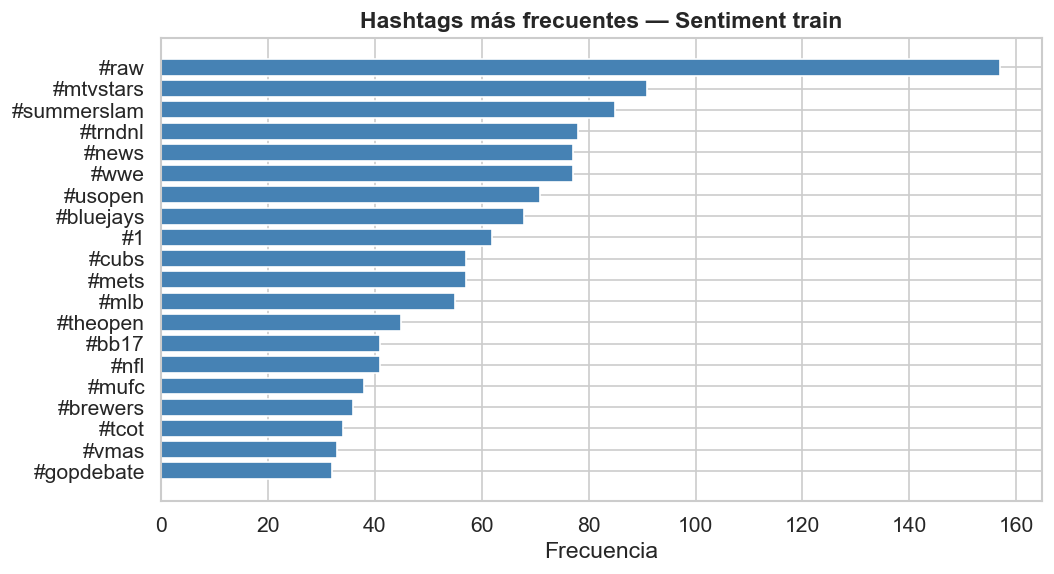

In [24]:
hashtags = top_tokens(train_df["text"], n=20, hashtags_only=True)

if hashtags:
    words, freqs = zip(*hashtags)
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(list(reversed(words)), list(reversed(freqs)), color="steelblue")
    ax.set_title("Hashtags más frecuentes — Sentiment train", fontweight="bold")
    ax.set_xlabel("Frecuencia")
    plt.tight_layout()
    plt.savefig(FIGURES / "sent_hashtags.png", bbox_inches="tight")
    plt.show()
else:
    print("No se encontraron hashtags en el conjunto de entrenamiento.")

### 1.6 Tabla resumen — Sentiment

In [25]:
rows = []
for split in ["train", "val", "test"]:
    sub = sent_df[sent_df["split"] == split]
    row = {"Split": split.capitalize(), "Total": len(sub)}
    for label in label_order:
        n = (sub["label_name"] == label).sum()
        row[label.capitalize()] = f"{n:,} ({n/len(sub)*100:.1f}%)"
    row["Longitud media (tokens)"] = f"{sub['n_tokens'].mean():.1f}"
    rows.append(row)

summary_sent = pd.DataFrame(rows).set_index("Split")
print("=== Tabla resumen: Sentiment Analysis ===")
print(summary_sent.to_string())

=== Tabla resumen: Sentiment Analysis ===
       Total       Negative         Neutral        Positive Longitud media (tokens)
Split                                                                              
Train  45615  7,093 (15.5%)  20,673 (45.3%)  17,849 (39.1%)                    19.2
Val     2000    312 (15.6%)     869 (43.5%)     819 (40.9%)                    19.4
Test   12284  3,972 (32.3%)   5,937 (48.3%)   2,375 (19.3%)                    14.9


---
## 2. Stance Detection

In [26]:
TARGETS = ["abortion", "atheism", "climate", "feminist", "hillary"]
TARGET_LABELS = {
    "abortion":  "Abortion",
    "atheism":   "Atheism",
    "climate":   "Climate Change",
    "feminist":  "Feminist Mvmt",
    "hillary":   "Hillary Clinton",
}

stance_dfs = {}
for target in TARGETS:
    df, mapping = load_task(DATA_ROOT/ "stance"/ target)
    df["target"] = target
    stance_dfs[target] = df

stance_map = mapping   # shared across targets: 0=none, 1=against, 2=favor
stance_all = pd.concat(stance_dfs.values(), ignore_index=True)
STANCE_LABEL_ORDER = [stance_map[k] for k in sorted(stance_map)]
STANCE_COLORS = {"none": "#7f7f7f", "against": "#d62728", "favor": "#2ca02c"}

print("Mapping:", stance_map)
print(f"Total tweets (todos los targets): {len(stance_all):,}")
stance_all.head(3)

Mapping: {0: 'none', 1: 'against', 2: 'favor'}
Total tweets (todos los targets): 4,163


,text,label,split,label_name,n_chars,n_tokens,target
0,we remind ourselves that love means to be will...,1,train,against,89,17,abortion
1,@user @user and most Islanders have different ...,0,train,none,104,14,abortion
2,"Life is #precious & so are babies, mothers, & ...",1,train,against,111,19,abortion


### 2.1 Distribución de muestras por target y split

In [27]:
rows = []
for target in TARGETS:
    df = stance_dfs[target]
    row = {"Target": TARGET_LABELS[target]}
    for split in ["train", "val", "test"]:
        row[split.capitalize()] = len(df[df["split"] == split])
    row["Total"] = len(df)
    rows.append(row)

split_table = pd.DataFrame(rows).set_index("Target")
print(split_table.to_string())
print(f"\nGrand total: {split_table['Total'].sum():,}")

                 Train  Val  Test  Total
Target                                  
Abortion           587   66   280    933
Atheism            461   52   220    733
Climate Change     355   40   169    564
Feminist Mvmt      597   67   285    949
Hillary Clinton    620   69   295    984

Grand total: 4,163


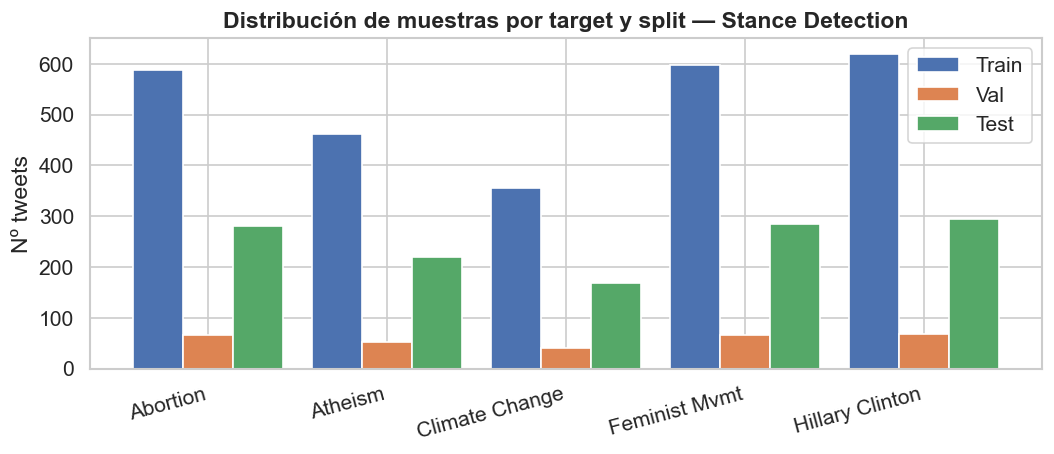

In [28]:
fig, ax = plt.subplots(figsize=(9, 4))

x = np.arange(len(TARGETS))
w = 0.28
split_colors = {"train": "#4C72B0", "val": "#DD8452", "test": "#55A868"}

for i, split in enumerate(["train", "val", "test"]):
    vals = [len(stance_dfs[t][stance_dfs[t]["split"] == split]) for t in TARGETS]
    ax.bar(x + (i-1)*w, vals, w, label=split.capitalize(), color=split_colors[split])

ax.set_xticks(x)
ax.set_xticklabels([TARGET_LABELS[t] for t in TARGETS], rotation=15, ha="right")
ax.set_ylabel("Nº tweets")
ax.set_title("Distribución de muestras por target y split — Stance Detection", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / "stance_split_distribution.png", bbox_inches="tight")
plt.show()

### 2.2 Distribución de etiquetas por target

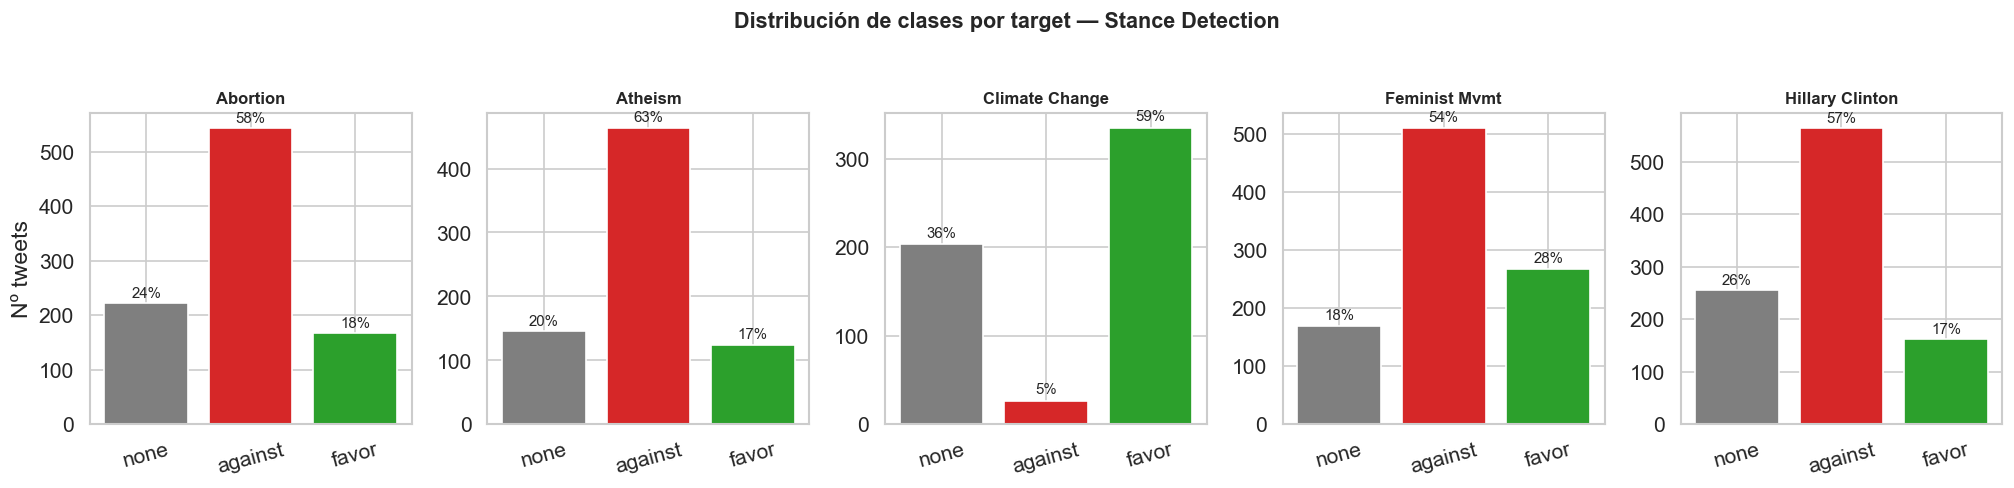

In [29]:
fig, axes = plt.subplots(1, 5, figsize=(17, 4), sharey=False)

for ax, target in zip(axes, TARGETS):
    df = stance_dfs[target]
    counts = df["label_name"].value_counts().reindex(STANCE_LABEL_ORDER)
    pcts   = counts / counts.sum() * 100
    bars = ax.bar(STANCE_LABEL_ORDER, counts,
                  color=[STANCE_COLORS[l] for l in STANCE_LABEL_ORDER])
    for bar, pct in zip(bars, pcts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f"{pct:.0f}%", ha="center", va="bottom", fontsize=9)
    ax.set_title(TARGET_LABELS[target], fontweight="bold", fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("Nº tweets" if target == "abortion" else "")
    ax.tick_params(axis="x", rotation=15)

fig.suptitle("Distribución de clases por target — Stance Detection", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "stance_label_distribution.png", bbox_inches="tight")
plt.show()

### 2.3 Desbalance de clases: heatmap comparativo

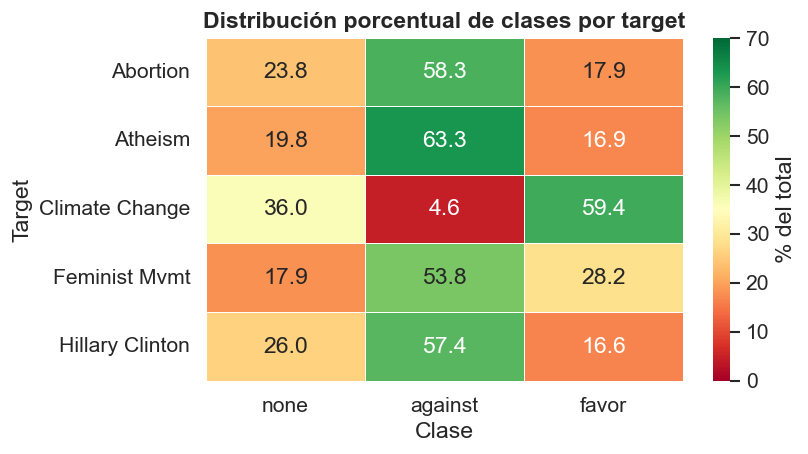

In [30]:
pct_matrix = pd.DataFrame(index=[TARGET_LABELS[t] for t in TARGETS],
                           columns=STANCE_LABEL_ORDER, dtype=float)

for target in TARGETS:
    df = stance_dfs[target]
    counts = df["label_name"].value_counts(normalize=True) * 100
    for label in STANCE_LABEL_ORDER:
        pct_matrix.loc[TARGET_LABELS[target], label] = counts.get(label, 0.0)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pct_matrix.astype(float), annot=True, fmt=".1f", cmap="RdYlGn",
            linewidths=0.5, ax=ax, cbar_kws={"label": "% del total"},
            vmin=0, vmax=70)
ax.set_title("Distribución porcentual de clases por target", fontweight="bold")
ax.set_xlabel("Clase")
ax.set_ylabel("Target")
plt.tight_layout()
plt.savefig(FIGURES / "stance_class_heatmap.png", bbox_inches="tight")
plt.show()

### 2.4 Longitud de tweets por target

/var/folders/bq/6pxdsh8107s4_tvgz_5dhtj40000gn/T/ipykernel_27217/377976623.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=stance_all, x="target", y="n_tokens",
/var/folders/bq/6pxdsh8107s4_tvgz_5dhtj40000gn/T/ipykernel_27217/377976623.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([TARGET_LABELS[t] for t in TARGETS], rotation=15, ha="right")


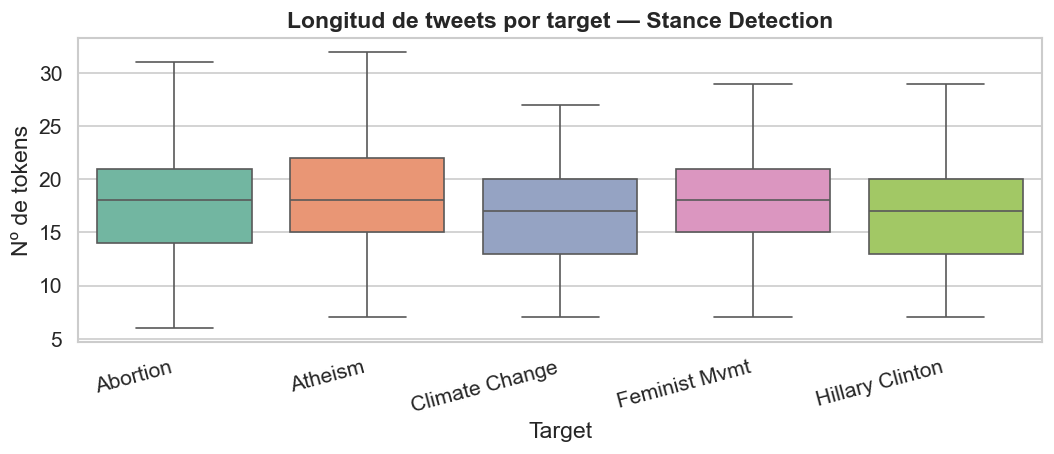

In [31]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(data=stance_all, x="target", y="n_tokens",
            order=TARGETS,
            palette="Set2",
            ax=ax)
ax.set_xticklabels([TARGET_LABELS[t] for t in TARGETS], rotation=15, ha="right")
ax.set_xlabel("Target")
ax.set_ylabel("Nº de tokens")
ax.set_title("Longitud de tweets por target — Stance Detection", fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES / "stance_tweet_length.png", bbox_inches="tight")
plt.show()

In [ ]:

# Longitud por clase (none/against/favor) — equivalente a sent_tweet_length.png
stance_train = stance_all[stance_all["split"] == "train"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label in STANCE_LABEL_ORDER:
    subset = stance_train[stance_train["label_name"] == label]["n_tokens"]
    axes[0].hist(subset, bins=25, alpha=0.6, label=label, color=STANCE_COLORS[label])
axes[0].set_xlabel("Nº de tokens")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribución de longitud por clase (train)", fontweight="bold")
axes[0].legend()
axes[0].set_xlim(0, 50)

sns.boxplot(data=stance_train, x="label_name", y="n_tokens",
            order=STANCE_LABEL_ORDER,
            palette=STANCE_COLORS,
            ax=axes[1])
axes[1].set_xlabel("Clase")
axes[1].set_ylabel("Nº de tokens")
axes[1].set_title("Longitud de tweets por clase (train)", fontweight="bold")

plt.suptitle("Stance Detection — Longitud por clase", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "stance_tweet_length_by_class.png", bbox_inches="tight")
plt.show()


### 2.5 Tokens más frecuentes por target (train)

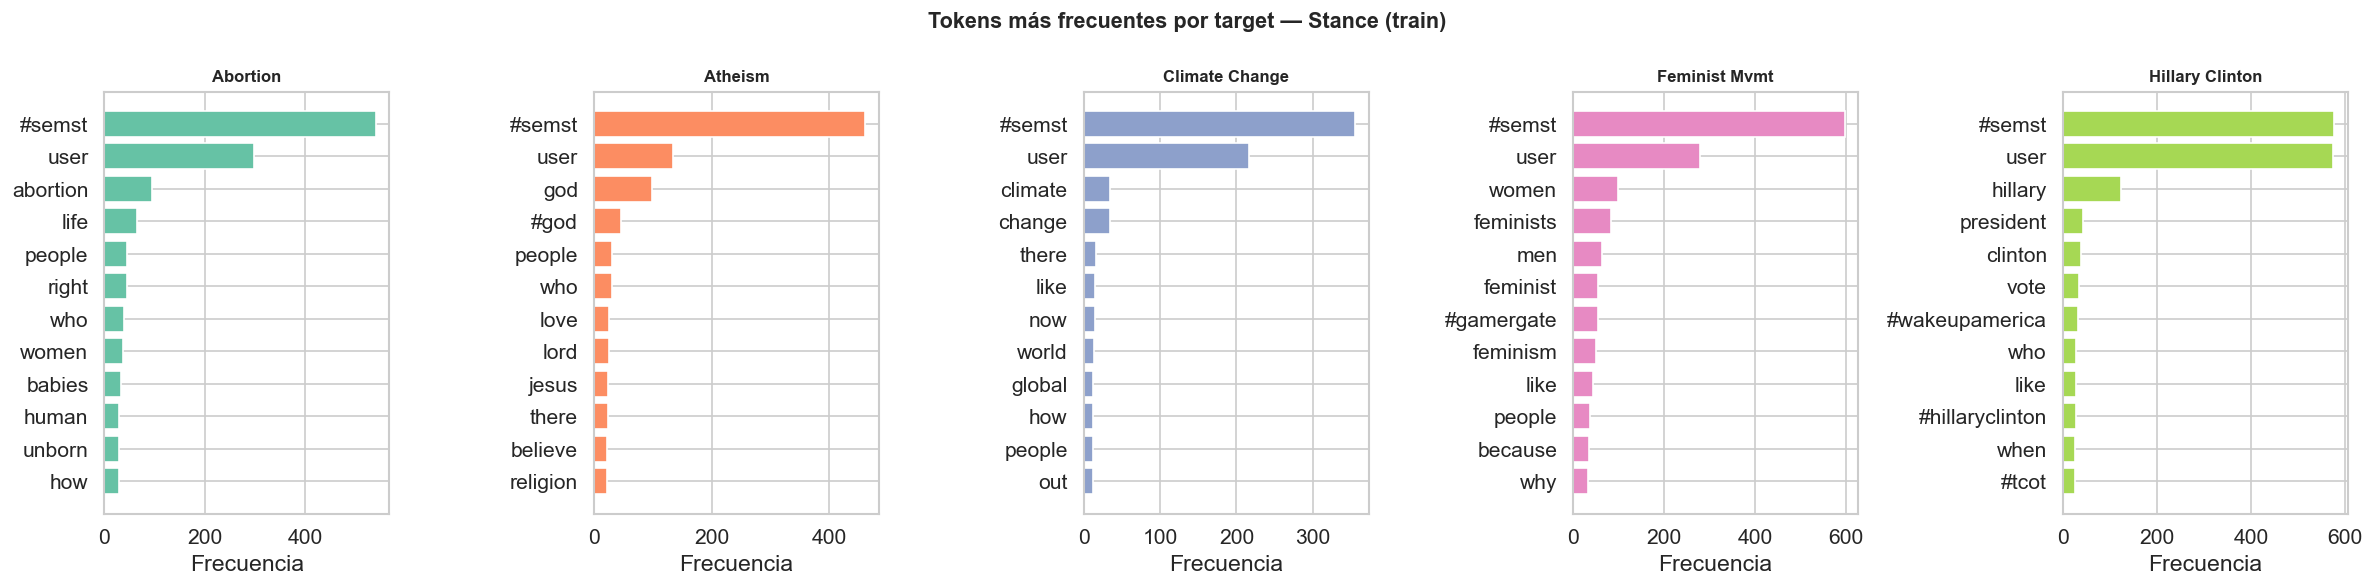

In [32]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
palette = sns.color_palette("Set2", 5)

for ax, target, color in zip(axes, TARGETS, palette):
    df = stance_dfs[target]
    train_texts = df[df["split"] == "train"]["text"]
    top = top_tokens(train_texts, n=12)
    words, freqs = zip(*top)
    ax.barh(list(reversed(words)), list(reversed(freqs)), color=color)
    ax.set_title(TARGET_LABELS[target], fontweight="bold", fontsize=10)
    ax.set_xlabel("Frecuencia")

fig.suptitle("Tokens más frecuentes por target — Stance (train)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES / "stance_top_tokens.png", bbox_inches="tight")
plt.show()

### 2.6 Tabla resumen — Stance

In [33]:
rows = []
for target in TARGETS:
    df = stance_dfs[target]
    row = {"Target": TARGET_LABELS[target], "Total": len(df)}
    counts = df["label_name"].value_counts()
    for label in STANCE_LABEL_ORDER:
        n = counts.get(label, 0)
        row[label.capitalize()] = f"{n} ({n/len(df)*100:.1f}%)"
    row["Long. media (tokens)"] = f"{df['n_tokens'].mean():.1f}"
    rows.append(row)

summary_stance = pd.DataFrame(rows).set_index("Target")
print("=== Tabla resumen: Stance Detection ===")
print(summary_stance.to_string())

=== Tabla resumen: Stance Detection ===
                 Total         None      Against        Favor Long. media (tokens)
Target                                                                            
Abortion           933  222 (23.8%)  544 (58.3%)  167 (17.9%)                 17.4
Atheism            733  145 (19.8%)  464 (63.3%)  124 (16.9%)                 18.1
Climate Change     564  203 (36.0%)    26 (4.6%)  335 (59.4%)                 16.6
Feminist Mvmt      949  170 (17.9%)  511 (53.8%)  268 (28.2%)                 17.7
Hillary Clinton    984  256 (26.0%)  565 (57.4%)  163 (16.6%)                 16.5


---
## 3. Comparativa: Sentiment vs Stance

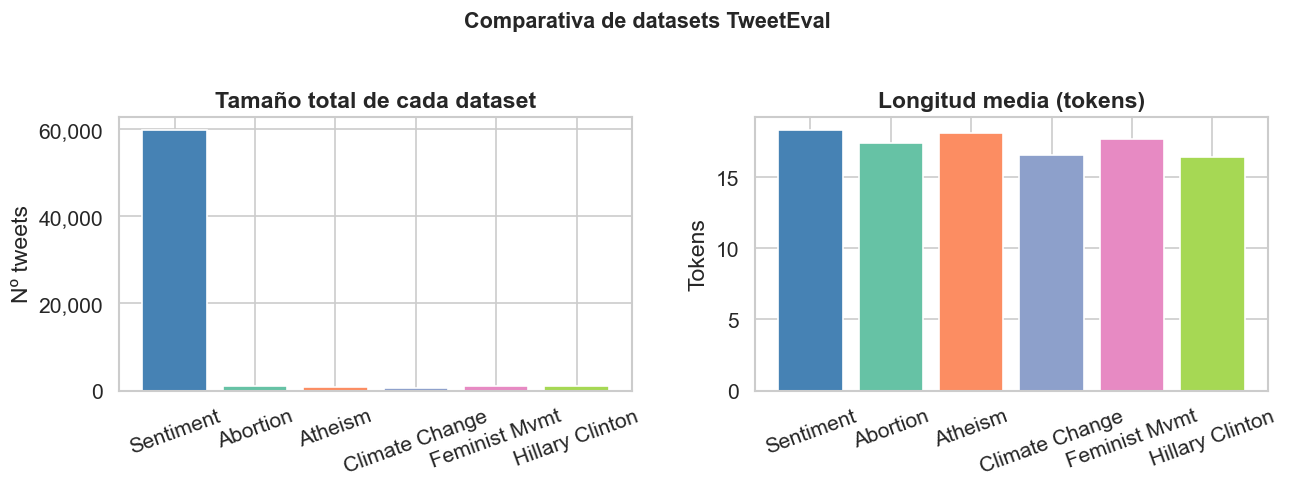

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Tamaño de datasets
ds_names  = ["Sentiment"] + [TARGET_LABELS[t] for t in TARGETS]
ds_counts = [len(sent_df)] + [len(stance_dfs[t]) for t in TARGETS]
colors    = ["steelblue"] + list(sns.color_palette("Set2", 5))

axes[0].bar(ds_names, ds_counts, color=colors)
axes[0].set_title("Tamaño total de cada dataset", fontweight="bold")
axes[0].set_ylabel("Nº tweets")
axes[0].tick_params(axis="x", rotation=20)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Longitud media de tweets
means = [sent_df["n_tokens"].mean()] + [stance_dfs[t]["n_tokens"].mean() for t in TARGETS]
axes[1].bar(ds_names, means, color=colors)
axes[1].set_title("Longitud media (tokens)", fontweight="bold")
axes[1].set_ylabel("Tokens")
axes[1].tick_params(axis="x", rotation=20)

plt.suptitle("Comparativa de datasets TweetEval", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "comparison_datasets.png", bbox_inches="tight")
plt.show()

---
## 4. Resumen ejecutivo

Los resultados de este análisis exploratorio revelan varios aspectos clave a tener en cuenta en la metodología:

**Sentiment Analysis:**
- Dataset de ~59,899 tweets con claro **desbalance de clases**: la clase `neutral` es minoritaria en todos los splits.
- Longitud media ~17 tokens, con alta varianza — coherente con la restricción de 140 caracteres de Twitter.
- El preprocesamiento de TweetEval ya normaliza `@usuario → @USER` y URLs → `HTTPURL`.

**Stance Detection:**
- 5 targets con **tamaños desiguales** (564–984 tweets): Climate change es el más pequeño.
- La clase `against` domina en casi todos los targets, especialmente en `atheism` y `hillary`.
- La clase `favor` es minoritaria, lo que puede sesgar el F1-avg hacia posturas negativas.
- Los tweets de stance son ligeramente **más cortos** que los de sentiment.

**Implicaciones para el modelado:**
- El desbalance de clases justifica el uso de **F1-macro** (sentiment) y **F1-avg favor/against** (stance) como métricas principales.
- El tamaño reducido de stance (especialmente climate: 564) hace que el fine-tuning sea más sensible a la inicialización; se recomienda early stopping.
- El vocabulario de Twitter (slang, hashtags, emojis, abreviaciones) justifica el uso de **BERTweet/RoBERTa-Twitter** preentrenados sobre tweets.